In [1]:
import oracledb
import pandas as pd
from tabulate import tabulate

# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_PESQUISA")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_pesquisa = pd.DataFrame(dados, columns=colunas)

# Garantir que DATA_PESQUISA esteja em formato datetime
df_pesquisa['DATA_PESQUISA'] = pd.to_datetime(df_pesquisa['DATA_PESQUISA'])

# Selecionar a pesquisa mais recente por FUNC_ID
idx_mais_recente = df_pesquisa.groupby('FUNC_ID')['DATA_PESQUISA'].idxmax()
df_mais_recente_pesquisa = df_pesquisa.loc[idx_mais_recente].reset_index(drop=True)

# Exibir resultado
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
print(tabulate(df_mais_recente_pesquisa, headers='keys', tablefmt='grid'))

print(f"Quantidade de registros: {len(df_mais_recente_pesquisa)}")


+----+-----------+---------------------+--------------------+-----------------+------------------------+------------------+----------------------+-----------------------------+----------------------------+-------------------------+
|    |   FUNC_ID | DATA_PESQUISA       |   ITEM_COMUNICACAO |   ITEM_FEEDBACK |   ITEM_TRABALHO_EQUIPE |   ITEM_LIDERANCA |   ITEM_VIDA_TRABALHO |   ITEM_APRENDIZADO_CARREIRA |   ITEM_FERRAMENTA_TRABALHO |   ITEM_SATISFACAO_GERAL |
+====+===========+=====================+====================+=================+========================+==================+======================+=============================+============================+=========================+
|  0 |         1 | 2025-01-05 00:00:00 |                  3 |               4 |                      5 |                4 |                    2 |                           1 |                          5 |                       5 |
+----+-----------+---------------------+--------------------+-----------

In [2]:
import oracledb
import pandas as pd
from tabulate import tabulate

# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_FEEDBACK")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_feedback = pd.DataFrame(dados, columns=colunas)

# Garantir que DATA_AVALIACAO esteja em formato datetime
df_feedback['DATA_AVALIACAO'] = pd.to_datetime(df_feedback['DATA_AVALIACAO'])

# Selecionar a pesquisa mais recente por FUNC_ID
idx_mais_recente = df_feedback.groupby('FUNC_ID')['DATA_AVALIACAO'].idxmax()
df_mais_recente_feedback = df_feedback.loc[idx_mais_recente].reset_index(drop=True)

# Exibir resultado
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
print(tabulate(df_mais_recente_feedback, headers='keys', tablefmt='grid'))

print(f"Quantidade de registros: {len(df_mais_recente_feedback)}")


+----+-----------+---------------+-----------+---------------------+---------------------+----------------+---------------+-------------------+-------------------+---------------------+------------+--------------------+
|    |   GERENTE |   COORDENADOR |   FUNC_ID | DATA_AVALIACAO      |   ATENDIMENTO_PRAZO |   PROATIVIDADE |   COMUNICACAO |   TRABALHO_EQUIPE |   DOMINIO_TECNICO |   QUALIDADE_ENTREGA |   INOVACAO |   DESEMPENHO_GERAL |
+====+===========+===============+===========+=====================+=====================+================+===============+===================+===================+=====================+============+====================+
|  0 |         2 |             2 |         1 | 2025-01-05 00:00:00 |                   3 |              1 |             3 |                 1 |                 5 |                   4 |          5 |                  2 |
+----+-----------+---------------+-----------+---------------------+---------------------+----------------+-------------

+----+-------------+--------------+--------------+-----------------------+
|    | QUADRANTE   |   DESEMPENHO |   SATISFACAO |   TOTAL_COLABORADORES |
+====+=============+==============+==============+=======================+
|  0 | Q1          |      4.75    |      4.75    |                     4 |
+----+-------------+--------------+--------------+-----------------------+
|  1 | Q2          |      1.71429 |      4.42857 |                     7 |
+----+-------------+--------------+--------------+-----------------------+
|  2 | Q3          |      3       |      2       |                     2 |
+----+-------------+--------------+--------------+-----------------------+
|  3 | Q4          |      4.8     |      1.8     |                     5 |
+----+-------------+--------------+--------------+-----------------------+


C:\Users\Paulo\AppData\Local\Temp\ipykernel_9652\3757284868.py:99: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


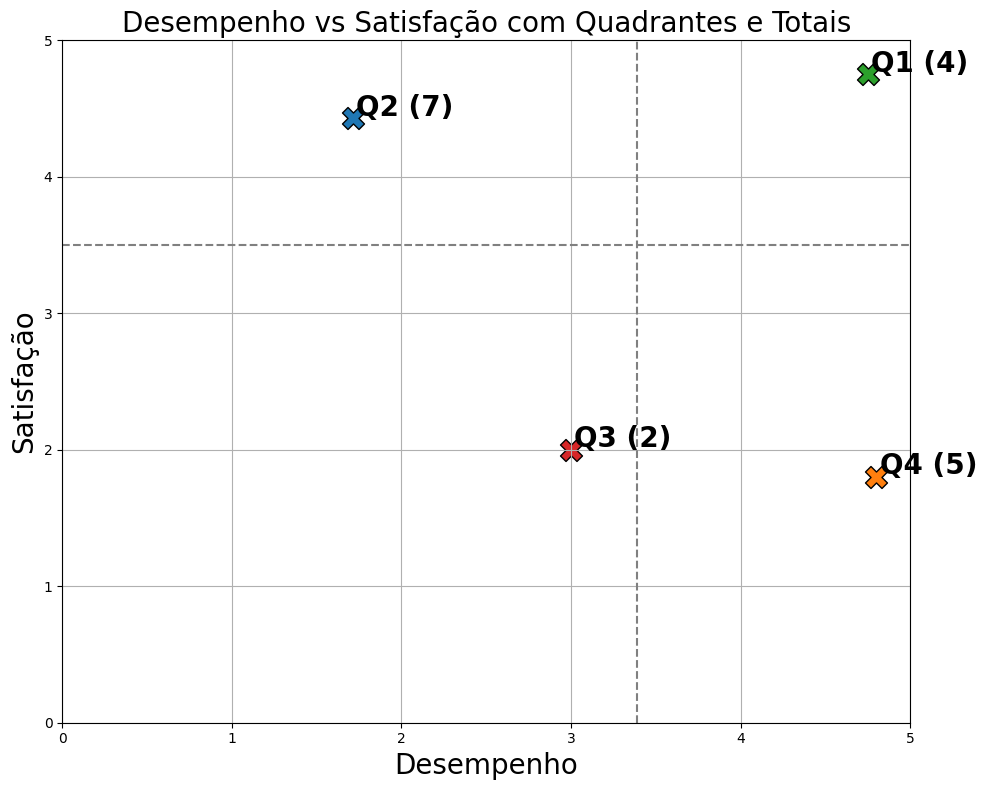

In [3]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Merge dos DataFrames
df_merged = pd.merge(
    df_mais_recente_pesquisa,
    df_mais_recente_feedback,
    left_on=['FUNC_ID', 'DATA_PESQUISA'],
    right_on=['FUNC_ID', 'DATA_AVALIACAO'],
    how='inner'
)

# Seleção e renomeação de colunas
df_resultado = df_merged[[
    'GERENTE',
    'COORDENADOR',
    'FUNC_ID',
    'DATA_AVALIACAO',
    'DESEMPENHO_GERAL',
    'ITEM_SATISFACAO_GERAL'
]].rename(columns={
    'DESEMPENHO_GERAL': 'DESEMPENHO',
    'ITEM_SATISFACAO_GERAL': 'SATISFACAO'
})


# Calcular medias
mediana_x = df_resultado['DESEMPENHO'].mean()
mediana_y = df_resultado['SATISFACAO'].mean()

# Classificar quadrantes
def classificar_quadrante(row):
    if row['DESEMPENHO'] >= mediana_x and row['SATISFACAO'] >= mediana_y:
        return 'Q1'
    elif row['DESEMPENHO'] < mediana_x and row['SATISFACAO'] >= mediana_y:
        return 'Q2'
    elif row['DESEMPENHO'] < mediana_x and row['SATISFACAO'] < mediana_y:
        return 'Q3'
    else:
        return 'Q4'

df_resultado['QUADRANTE'] = df_resultado.apply(classificar_quadrante, axis=1)

# Consolidar o DataFrame por quadrante
df_consolidado = df_resultado.groupby('QUADRANTE').agg({
    'DESEMPENHO': 'mean',
    'SATISFACAO': 'mean',
    'FUNC_ID': 'count'  # Conta o número de colaboradores por quadrante
}).rename(columns={'FUNC_ID': 'TOTAL_COLABORADORES'}).reset_index()

# Exibir o novo DataFrame consolidado
print(tabulate(df_consolidado, headers='keys', tablefmt='grid'))

import matplotlib.pyplot as plt
import seaborn as sns

# Cores para os quadrantes
cores_quadrantes = {
    'Q1': '#2ca02c',  # Verde
    'Q2': '#1f77b4',  # Azul
    'Q3': '#d62728',  # Vermelho
    'Q4': '#ff7f0e'   # Laranja
}

# Criar gráfico de dispersão
plt.figure(figsize=(10, 8))


# Linhas divisórias dos quadrantes
plt.axvline(x=mediana_x, color='gray', linestyle='--')
plt.axhline(y=mediana_y, color='gray', linestyle='--')

# Adicionar os pontos médios dos quadrantes com rótulo de quantidade
for _, row in df_consolidado.iterrows():
    plt.scatter(
        row['DESEMPENHO'],
        row['SATISFACAO'],
        color=cores_quadrantes[row['QUADRANTE']],
        s=250,
        marker='X',
        edgecolor='black'
    )
    plt.text(
        row['DESEMPENHO'] + 0.02,
        row['SATISFACAO'] + 0.02,
        f"{row['QUADRANTE']} ({row['TOTAL_COLABORADORES']})",
        fontsize=20,
        color='black',
        weight='bold'
    )

plt.title('Desempenho vs Satisfação com Quadrantes e Totais', fontsize=20)
plt.xlabel('Desempenho', fontsize=20)
plt.ylabel('Satisfação', fontsize=20)
plt.xlim(0, 5)  # Limite do eixo X de 0 a 5
plt.ylim(0, 5)  # Limite do eixo Y de 0 a 5
plt.legend().remove()
plt.grid(True)
plt.tight_layout()
plt.show()


In [4]:
import oracledb
import pandas as pd
from tabulate import tabulate

# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_EQUIPE_PROJ")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_equipe_proj = pd.DataFrame(dados, columns=colunas)




# Merge entre df_equipe_proj e df_resultado com base em FUNC_ID
df_equipe_com_resultado = pd.merge(
    df_equipe_proj,
    df_resultado[['FUNC_ID', 'DESEMPENHO', 'SATISFACAO', 'QUADRANTE']],
    on='FUNC_ID'
)

# Consolidar por PROJ_ID com médias de desempenho e satisfação
df_consolidado_proj = df_equipe_com_resultado.groupby('PROJ_ID').agg({
    'DESEMPENHO': 'mean',
    'SATISFACAO': 'mean'
}).reset_index()



# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_PROJ")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_cad_proj = pd.DataFrame(dados, columns=colunas)


# Merge entre df_consolidado_proj e df_cad_proj com base em PROJ_ID
df_proj_completo = pd.merge(
    df_cad_proj,
    df_consolidado_proj,
    on='PROJ_ID',
    how='left'  # ou 'inner' se quiser apenas os projetos com dados consolidados
)

# Calcular o intervalo de dias
df_proj_completo['DURACAO_DIAS'] = (df_proj_completo['DATA_FIM'] - df_proj_completo['DATA_INI']).dt.days

# Calcular a razão entre saldo diário e duração em dias
df_proj_completo['PER_SALDO_TEMPO'] = df_proj_completo['SALDO_DIA'] / df_proj_completo['DURACAO_DIAS']

df_proj_completo.drop(columns=['DESCRICAO', 'DATA_INI', 'DATA_FIM'], inplace=True)



# Agrupar por PROJ_NIVEL e calcular médias de desempenho e satisfação
df_resumo_nivel = df_proj_completo.groupby('PROJ_NIVEL').agg({
    'DESEMPENHO': 'mean',
    'SATISFACAO': 'mean',
    'PROJ_ID': 'count'  # opcional: conta quantos projetos por nível
}).rename(columns={'PROJ_ID': 'QTD_PROJETOS'}).reset_index()

# Agrupar por PROJ_PRIORIDADE e calcular médias de desempenho e satisfação
df_resumo_nivel_prioridade = df_proj_completo.groupby('PROJ_PRIORIDADE').agg({
    'DESEMPENHO': 'mean',
    'SATISFACAO': 'mean',
    'PROJ_ID': 'count'  # opcional: conta quantos projetos por nível
}).rename(columns={'PROJ_ID': 'QTD_PROJETOS'}).reset_index()

# Exibir o resumo
print(tabulate(df_resumo_nivel, headers='keys', tablefmt='grid', floatfmt=".2f"))

# Exibir o resumo
print(tabulate(df_resumo_nivel_prioridade, headers='keys', tablefmt='grid', floatfmt=".2f"))

# Exibir resultado com nova coluna
print(tabulate(df_proj_completo, headers='keys', tablefmt='grid'))
print(f"Quantidade de projetos após o merge: {len(df_proj_completo)}")


+----+--------------+--------------+--------------+----------------+
|    | PROJ_NIVEL   |   DESEMPENHO |   SATISFACAO |   QTD_PROJETOS |
+====+==============+==============+==============+================+
|  0 | Estratégico  |         3.26 |         3.44 |              3 |
+----+--------------+--------------+--------------+----------------+
|  1 | Operacional  |         3.39 |         3.50 |              2 |
+----+--------------+--------------+--------------+----------------+
|  2 | Tático       |         3.47 |         3.53 |              5 |
+----+--------------+--------------+--------------+----------------+
+----+-------------------+--------------+--------------+----------------+
|    | PROJ_PRIORIDADE   |   DESEMPENHO |   SATISFACAO |   QTD_PROJETOS |
+====+===================+==============+==============+================+
|  0 | ALTA              |         3.39 |         3.50 |              4 |
+----+-------------------+--------------+--------------+----------------+
|  1 | BA

In [5]:
import numpy as np
import pandas as pd
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Selecionar apenas as colunas desejadas do df_feedback
df_feedback_reduzido = df_feedback[['FUNC_ID', 'DATA_AVALIACAO', 'DESEMPENHO_GERAL']]

# Realizar o merge com base em FUNC_ID e datas iguais
df_pesquisa_com_feedback = pd.merge(
    df_pesquisa,
    df_feedback_reduzido,
    left_on=['FUNC_ID', 'DATA_PESQUISA'],
    right_on=['FUNC_ID', 'DATA_AVALIACAO'],
    how='left'  # ou 'inner' se quiser apenas os registros com match
)

# Criar nova coluna com classificação textual de desempenho
condicoes = [
    df_pesquisa_com_feedback['DESEMPENHO_GERAL'] < 3,
     df_pesquisa_com_feedback['DESEMPENHO_GERAL'] ==3,
    df_pesquisa_com_feedback['DESEMPENHO_GERAL'] >= 4,
]

resultados = [
    "Abaixo do Esperado",
    "Dentro do Esperado",
    "Acima do Esperado"
]

df_pesquisa_com_feedback['CLASSIFICACAO_DESEMPENHO'] = np.select(condicoes, resultados, default=None)

# Remover registros sem classificação de desempenho
df_modelo = df_pesquisa_com_feedback.dropna(subset=['CLASSIFICACAO_DESEMPENHO'])

# Selecionar variáveis preditoras e alvo
X = df_modelo[['ITEM_COMUNICACAO', 'ITEM_FEEDBACK', 'ITEM_TRABALHO_EQUIPE', 'ITEM_LIDERANCA',
               'ITEM_VIDA_TRABALHO', 'ITEM_APRENDIZADO_CARREIRA', 'ITEM_FERRAMENTA_TRABALHO',
               'ITEM_SATISFACAO_GERAL']]
y = df_modelo['CLASSIFICACAO_DESEMPENHO']

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar modelo Random Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

# Avaliar acurácia
y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {acuracia:.2%}")

# Entrada simulada de um colaborador
entrada_usuario = pd.DataFrame({
    'ITEM_COMUNICACAO': [3],
    'ITEM_FEEDBACK': [3],
    'ITEM_TRABALHO_EQUIPE': [3],
    'ITEM_LIDERANCA': [3],
    'ITEM_VIDA_TRABALHO': [2],
    'ITEM_APRENDIZADO_CARREIRA': [2],
    'ITEM_FERRAMENTA_TRABALHO': [5],
    'ITEM_SATISFACAO_GERAL': [5]
})

# Prever classificação de desempenho
desempenho_previsto = modelo.predict(entrada_usuario)
print(f"Considerando avaliação de satisfação, o desempenho deste colaborador será: {desempenho_previsto[0]}")

# Exibir resultado completo
print(tabulate(df_pesquisa_com_feedback, headers='keys', tablefmt='grid'))
print(f"Total de registros combinados: {len(df_pesquisa_com_feedback)}")

Acurácia do modelo: 47.37%
Considerando avaliação de satisfação, o desempenho deste colaborador será: Abaixo do Esperado
+----+-----------+---------------------+--------------------+-----------------+------------------------+------------------+----------------------+-----------------------------+----------------------------+-------------------------+---------------------+--------------------+----------------------------+
|    |   FUNC_ID | DATA_PESQUISA       |   ITEM_COMUNICACAO |   ITEM_FEEDBACK |   ITEM_TRABALHO_EQUIPE |   ITEM_LIDERANCA |   ITEM_VIDA_TRABALHO |   ITEM_APRENDIZADO_CARREIRA |   ITEM_FERRAMENTA_TRABALHO |   ITEM_SATISFACAO_GERAL | DATA_AVALIACAO      |   DESEMPENHO_GERAL | CLASSIFICACAO_DESEMPENHO   |
+====+===========+=====================+====================+=================+========================+==================+======================+=============================+============================+=========================+=====================+==================

Gráfico de barras comparando os resultados médios dos gerentes Paulo e Samuel foi salvo como comparacao_gerentes.png


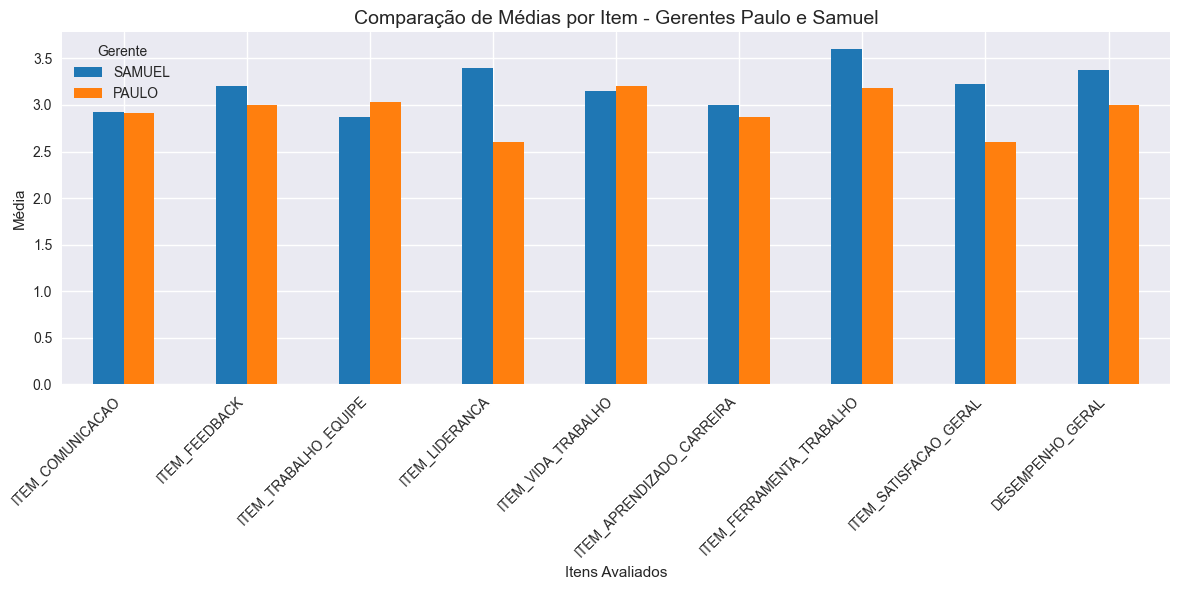

In [6]:
import oracledb
import pandas as pd
from tabulate import tabulate
import numpy as np
import matplotlib.pyplot as plt


# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_RH")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_cad_funcionarios = pd.DataFrame(dados, columns=colunas)

colunas_para_media = [
    'ITEM_COMUNICACAO',
    'ITEM_FEEDBACK',
    'ITEM_TRABALHO_EQUIPE',
    'ITEM_LIDERANCA',
    'ITEM_VIDA_TRABALHO',
    'ITEM_APRENDIZADO_CARREIRA',
    'ITEM_FERRAMENTA_TRABALHO',
    'ITEM_SATISFACAO_GERAL',
    'DESEMPENHO_GERAL'
]

# Agrupar por FUNC_ID e calcular a média
df_media_por_funcionario = df_pesquisa_com_feedback.groupby('FUNC_ID')[colunas_para_media].mean().reset_index()


df_funcionarios_com_medias = pd.merge(
    df_cad_funcionarios,
    df_media_por_funcionario,
    on='FUNC_ID'
)

# Selecionar apenas as colunas desejadas
df_gerencia = df_mais_recente_feedback[['FUNC_ID', 'GERENTE', 'COORDENADOR']]

# Realizar o merge com base em FUNC_ID
df_funcionarios_completo = pd.merge(
    df_funcionarios_com_medias,
    df_gerencia,
    on='FUNC_ID'
)

# Agrupar por FUNC_ID e calcular a média
df_media_por_gerente = df_funcionarios_completo.groupby('GERENTE')[colunas_para_media].mean().reset_index()

condicoes = [
    df_media_por_gerente['GERENTE'] == 1,
    df_media_por_gerente['GERENTE'] == 2
]

resultados = [
    "SAMUEL",
    "PAULO"
]

# Criar nova coluna com nome do gerente
df_media_por_gerente['NOME_GERENTE'] = np.select(condicoes, resultados, default="OUTRO")

df_media_por_gerente = df_media_por_gerente.drop(columns=['GERENTE'])

# Transpor o DataFrame para facilitar a plotagem
df_plot = df_media_por_gerente.set_index('NOME_GERENTE').T

# Estilo do gráfico
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar gráfico de barras
df_plot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])

# Ajustes visuais
ax.set_title('Comparação de Médias por Item - Gerentes Paulo e Samuel', fontsize=14)
ax.set_ylabel('Média')
ax.set_xlabel('Itens Avaliados')
ax.legend(title='Gerente')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Salvar gráfico
output_path = '/mnt/data/comparacao_gerentes.png'
plt.savefig(output_path)

print("Gráfico de barras comparando os resultados médios dos gerentes Paulo e Samuel foi salvo como comparacao_gerentes.png")



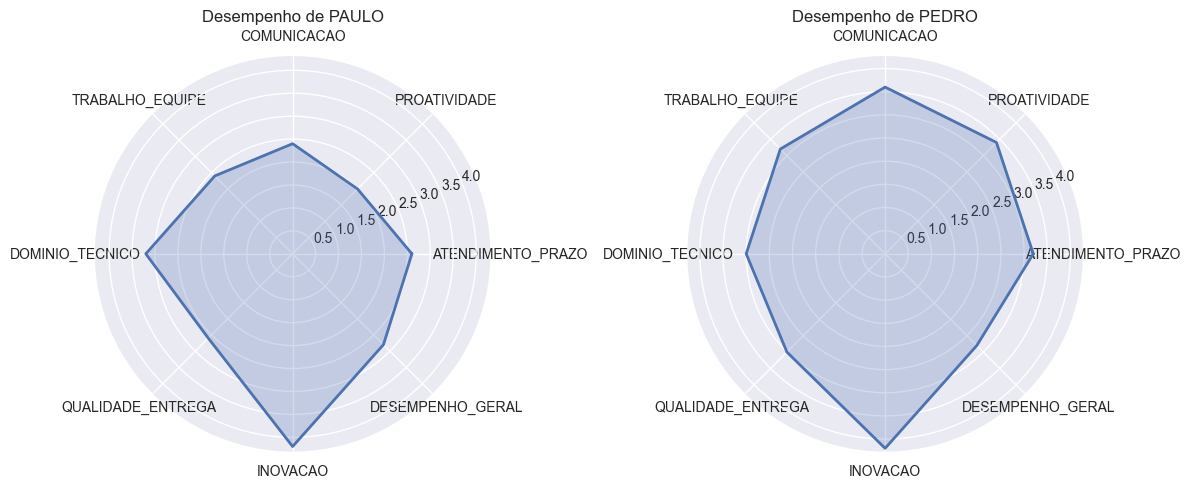

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Exibir resultado com nova coluna

colunas_avaliacao = [
    'ATENDIMENTO_PRAZO', 'PROATIVIDADE', 'COMUNICACAO', 'TRABALHO_EQUIPE',
    'DOMINIO_TECNICO', 'QUALIDADE_ENTREGA', 'INOVACAO', 'DESEMPENHO_GERAL'
]

# Agrupar por ID_func e calcular a média
df_feedback_media = df_feedback.groupby('FUNC_ID')[colunas_avaliacao].mean().reset_index()

df_funcionarios = df_cad_funcionarios[['FUNC_ID', 'FUNC_NOME']]

# Realizar o merge com base em FUNC_ID
df_feedback_media = pd.merge(
    df_feedback_media,
    df_funcionarios,
    on='FUNC_ID'
)

df_feedback_media = df_feedback_media.drop(columns=['FUNC_ID'], errors='ignore')


# Lista de métricas
metricas = [
    'ATENDIMENTO_PRAZO', 'PROATIVIDADE', 'COMUNICACAO', 'TRABALHO_EQUIPE',
    'DOMINIO_TECNICO', 'QUALIDADE_ENTREGA', 'INOVACAO', 'DESEMPENHO_GERAL'
]

# Selecionar dois funcionários
funcionarios = df_feedback_media['FUNC_NOME'].unique()[:2]  # os dois primeiros

# Preparar dados
dados = []
for nome in funcionarios:
    valores = df_feedback_media[df_feedback_media['FUNC_NOME'] == nome][metricas].values.flatten().tolist()
    valores += valores[:1]  # fechar o gráfico
    dados.append((nome, valores))

# Ângulos para radar
num_vars = len(metricas)
angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angulos += angulos[:1]

# Criar subplots lado a lado
fig, axs = plt.subplots(1, 2, subplot_kw=dict(polar=True), figsize=(12, 6))

for ax, (nome, valores) in zip(axs, dados):
    ax.plot(angulos, valores, linewidth=2)
    ax.fill(angulos, valores, alpha=0.25)
    ax.set_thetagrids(np.degrees(angulos[:-1]), metricas)
    ax.set_title(f'Desempenho de {nome}', fontsize=12)

plt.tight_layout()
plt.show()
   

C:\Users\Paulo\AppData\Local\Temp\ipykernel_9652\2670261097.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_feedback_long, x='FUNC_NOME', y='NOTA_AVAL', palette='Set2')


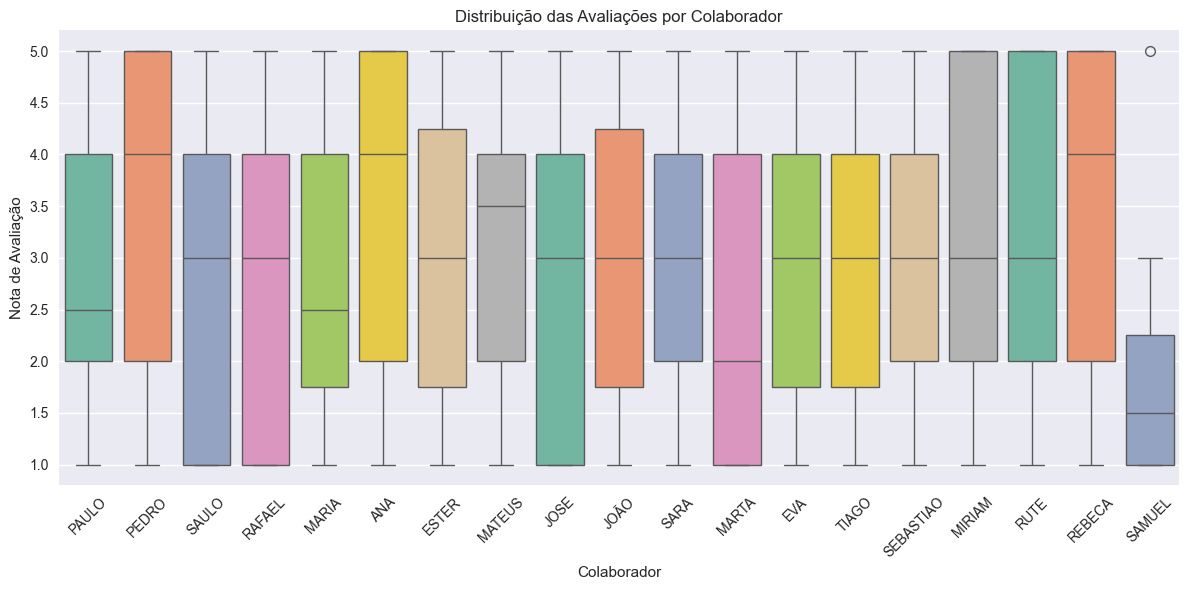

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

# Realizar o merge com base em FUNC_ID
df_feedback = pd.merge(df_feedback, df_funcionarios, on='FUNC_ID')

# Selecionar colunas relevantes
colunas = [
    'FUNC_NOME', 'ATENDIMENTO_PRAZO', 'PROATIVIDADE', 'COMUNICACAO', 'TRABALHO_EQUIPE',
    'DOMINIO_TECNICO', 'QUALIDADE_ENTREGA', 'INOVACAO', 'DESEMPENHO_GERAL'
]
df_feedback = df_feedback[colunas]

# Lista de colunas de avaliação
colunas_avaliacao = [
    'ATENDIMENTO_PRAZO', 'PROATIVIDADE', 'COMUNICACAO', 'TRABALHO_EQUIPE',
    'DOMINIO_TECNICO', 'QUALIDADE_ENTREGA', 'INOVACAO', 'DESEMPENHO_GERAL'
]

# Transpor colunas para linhas
df_feedback_long = df_feedback.melt(
    id_vars=['FUNC_NOME'],
    value_vars=colunas_avaliacao,
    var_name='CRITERIO_AVAL',
    value_name='NOTA_AVAL'
)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_feedback_long, x='FUNC_NOME', y='NOTA_AVAL', palette='Set2')
plt.title('Distribuição das Avaliações por Colaborador')
plt.xlabel('Colaborador')
plt.ylabel('Nota de Avaliação')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

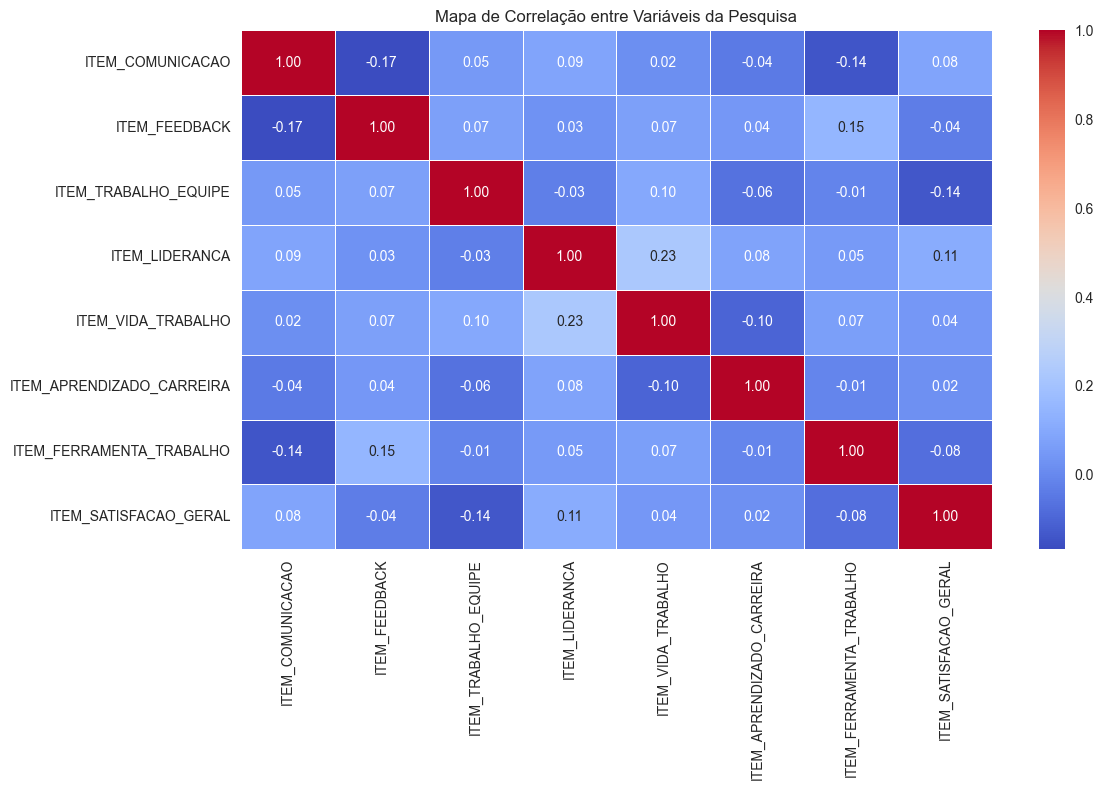

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import oracledb
import pandas as pd
from tabulate import tabulate

# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_PESQUISA")
colunas = [col[0] for col in cursor.description]
dados = cursor.fetchall()
df_pesquisa = pd.DataFrame(dados, columns=colunas)


df_numerico = df_pesquisa.select_dtypes(include='number')

# Remover a coluna FUNC_ID, se existir
df_numerico = df_numerico.drop(columns=['FUNC_ID'], errors='ignore')

# Calcular a matriz de correlação
matriz_correlacao = df_numerico.corr()


# Visualizar com mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Correlação entre Variáveis da Pesquisa')
plt.tight_layout()
plt.show()



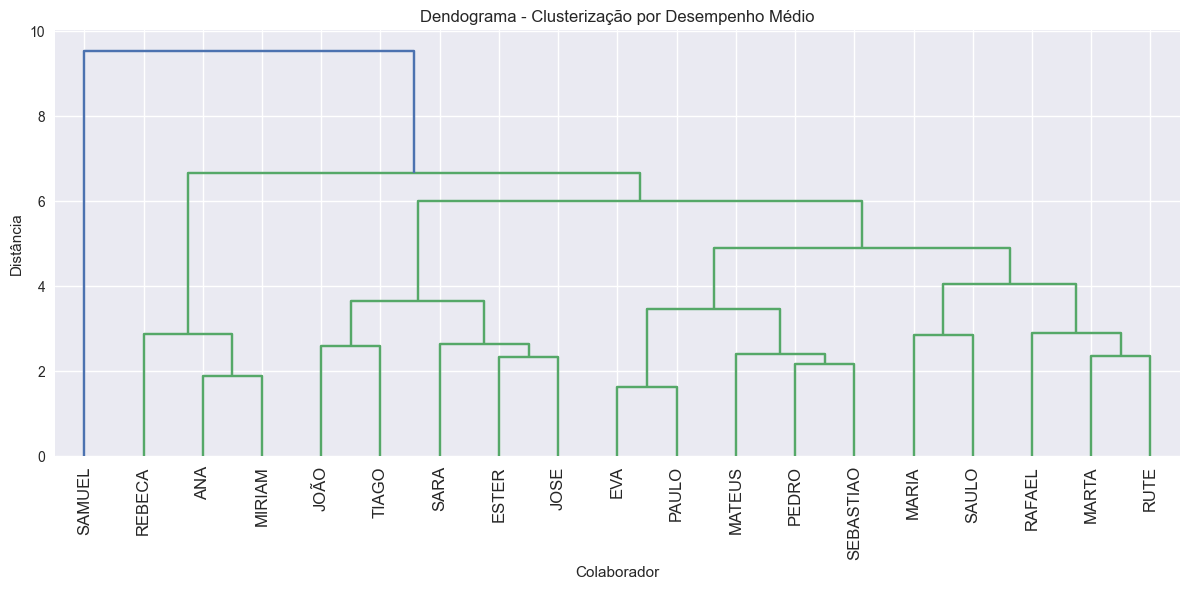

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
import oracledb

# Conexão com o banco de dados Oracle
conn = oracledb.connect(
    user='rm567787',
    password='281083',
    dsn='oracle.fiap.com.br:1521/ORCL'
)
cursor = conn.cursor()

# Carregar tabela de feedback
cursor.execute("SELECT * FROM GS_2025_2SEM_CAD_FEEDBACK")
colunas_feedback = [col[0] for col in cursor.description]
dados_feedback = cursor.fetchall()
df_feedback = pd.DataFrame(dados_feedback, columns=colunas_feedback)

# Merge das tabelas
df_cad_funcionario_media = pd.merge(df_feedback, df_funcionarios, on='FUNC_ID')

variaveis_avaliacao = [
    'ATENDIMENTO_PRAZO', 'PROATIVIDADE', 'COMUNICACAO', 'TRABALHO_EQUIPE',
    'DOMINIO_TECNICO', 'QUALIDADE_ENTREGA', 'INOVACAO', 'DESEMPENHO_GERAL'
]

# Agrupar por FUNC_NOME e calcular a média
df_cad_funcionario_media = df_cad_funcionario_media.groupby('FUNC_NOME')[variaveis_avaliacao].mean().reset_index()

X = df_cad_funcionario_media[variaveis_avaliacao]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar KMeans (opcional: definir número de clusters)
kmeans = KMeans(n_clusters=8, random_state=42)
df_cad_funcionario_media['CLUSTER_KMEANS'] = kmeans.fit_predict(X_scaled)

# Gerar dendograma
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=df_cad_funcionario_media['FUNC_NOME'].values, leaf_rotation=90)
plt.title('Dendograma - Clusterização por Desempenho Médio')
plt.xlabel('Colaborador')
plt.ylabel('Distância')
plt.tight_layout()
plt.show()



In [26]:
print(df_funcionarios)

    FUNC_ID  FUNC_NOME
0         1      PAULO
1         2      PEDRO
2         3      SAULO
3         4     RAFAEL
4         5      MARIA
5         6        ANA
6         7      ESTER
7         8     MATEUS
8         9       JOSE
9        10       JOÃO
10       11       SARA
11       12      MARTA
12       13        EVA
13       14      TIAGO
14       15     SAMUEL
15       16      SAULO
16       17  SEBASTIAO
17       18     MIRIAM
18       19       RUTE
19       20     REBECA
